In [1]:
# ============================================================
# STAGE 3 CONFIG
# Combinatorial contact selection / current steering
# No exact-K constraint; sparsity is learned via penalty
# ============================================================

import os
import time
import numpy as np
from dataclasses import dataclass
from typing import Optional, Tuple, List, Dict

# -------- Parallelism --------
N_JOBS = 25
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["NUMEXPR_NUM_THREADS"] = "1"

# -------- Stage 3 structure --------
N_CONTACTS = 16                  # binary contact-selection variables
BUDGETS = [10, 20, 30, 40]       # evaluation budgets
SEEDS_SWEEP = 30                 # repeated runs per method

# -------- Fixed temporal DBS settings for Stage 3 --------
# Stage 3 isolates the combinatorial contact problem.
F_HZ = 130.0
PW_US = 240.0
PW_S = PW_US * 1e-6

# -------- Effective per-contact stimulation scale --------
# Chosen so the efficacy curve is nontrivial but not saturating too quickly
A_UNIT = 0.25

# -------- Normalization constants for safety proxies --------
A_MAX = 1.5
PW_MAX_US = 240.0
PW_MAX_S = PW_MAX_US * 1e-6

# -------- Objective weights --------
LAMBDA_COUNT   = 0.18   # sparsity penalty (fewer active contacts preferred)
LAMBDA_ENERGY  = 0.20   # energy/battery penalty
LAMBDA_RISK    = 0.22   # side-effect proxy penalty
LAMBDA_OVERLAP = 0.30   # pairwise overlap / spread penalty
LAMBDA_QD      = 0.40   # charge-density soft penalty

# -------- Charge density soft threshold --------
QD_SOFT_TARGET = 0.55

# -------- Optional hard cap (kept high so the space stays rich) --------
INFEAS_COST = 1e6

# -------- QAOA settings --------
QAOA_P = 1
QAOA_SHOTS = 256
QAOA_MAXITER = 30

print("Stage 3 config loaded.")
print("N_CONTACTS =", N_CONTACTS)
print("Budgets =", BUDGETS)


Stage 3 config loaded.
N_CONTACTS = 16
Budgets = [10, 20, 30, 40]


In [2]:
# ============================================================
# STN–GPe model and beta metric
# We use the simulator only to fit beta_ratio(A_eff),
# then Stage 3 becomes a direct combinatorial QUBO problem.
# ============================================================

from scipy.signal import welch

def beta_band_power(signal: np.ndarray, fs: float, band: Tuple[float, float] = (13.0, 30.0)) -> float:
    f, P = welch(signal, fs=fs, nperseg=min(len(signal), 8192))
    lo, hi = band
    mask = (f >= lo) & (f <= hi)
    return float(np.trapz(P[mask], f[mask]))

def tanh_act(x: float, gain: float) -> float:
    return float(np.tanh(gain * x))

@dataclass(frozen=True)
class STNGPePatient:
    tau_stn: float
    tau_gpe: float
    delay_stn_to_gpe: float
    delay_gpe_to_stn: float
    w_stn_to_gpe: float
    w_gpe_to_stn: float
    I_cort: float
    I_gpe_bias: float
    gain_stn: float
    gain_gpe: float
    noise_std: float = 0.0

@dataclass(frozen=True)
class DBSParams:
    f_hz: float
    A: float
    pw_s: float

@dataclass(frozen=True)
class SimParams:
    T: float = 2.0
    dt: float = 1e-4
    discard: float = 0.2
    seed: int = 0

SIM = SimParams(T=2.0, dt=1e-4, discard=0.2, seed=0)
BETA_BAND = (13.0, 30.0)

MAIN_PATIENT = STNGPePatient(
    tau_stn=0.009480108684355502,
    tau_gpe=0.01568342986890998,
    delay_stn_to_gpe=0.005856049933455449,
    delay_gpe_to_stn=0.004355096988711622,
    w_stn_to_gpe=0.8766085173129406,
    w_gpe_to_stn=0.8007248587605185,
    I_cort=0.21584549577209655,
    I_gpe_bias=0.0,
    gain_stn=2.418440027526686,
    gain_gpe=2.4195288944990088,
    noise_std=0.0
)

def simulate_stn_gpe(patient: STNGPePatient, dbs: Optional[DBSParams], sim: SimParams):
    rng = np.random.default_rng(sim.seed)
    n = int(sim.T / sim.dt)
    t = np.arange(n) * sim.dt

    stn = np.zeros(n, dtype=float)
    gpe = np.zeros(n, dtype=float)
    stn[0], gpe[0] = 0.1, 0.1

    d_sg = max(1, int(patient.delay_stn_to_gpe / sim.dt))
    d_gs = max(1, int(patient.delay_gpe_to_stn / sim.dt))

    if dbs is None or dbs.A == 0 or dbs.f_hz == 0 or dbs.pw_s == 0:
        f = 0.0; A = 0.0; pw = 0.0
    else:
        f = float(dbs.f_hz); A = float(dbs.A); pw = float(dbs.pw_s)

    period = 1.0 / f if f > 0 else None
    next_pulse = 0.0
    pulse_end = -1.0

    for k in range(n - 1):
        tt = t[k]

        Idbs = 0.0
        if f > 0:
            if tt >= next_pulse:
                pulse_end = next_pulse + pw
                next_pulse += period
            if tt < pulse_end:
                Idbs = A

        stn_del = stn[k - d_sg] if k >= d_sg else stn[0]
        gpe_del = gpe[k - d_gs] if k >= d_gs else gpe[0]

        ns = patient.noise_std * rng.standard_normal()
        ng = patient.noise_std * rng.standard_normal()

        inp_stn = patient.I_cort - patient.w_gpe_to_stn * gpe_del + Idbs + ns
        inp_gpe = patient.w_stn_to_gpe * stn_del + patient.I_gpe_bias + ng

        Fstn = tanh_act(inp_stn, patient.gain_stn)
        Fgpe = tanh_act(inp_gpe, patient.gain_gpe)

        dstn = (-stn[k] + Fstn) / patient.tau_stn
        dgpe = (-gpe[k] + Fgpe) / patient.tau_gpe

        stn[k + 1] = stn[k] + sim.dt * dstn
        gpe[k + 1] = gpe[k] + sim.dt * dgpe

    start = int(sim.discard / sim.dt)
    y = (stn - gpe)[start:]
    tt = t[start:]
    return tt, y

# Baseline beta
t0, y0 = simulate_stn_gpe(MAIN_PATIENT, None, SIM)
FS = 1.0 / (t0[1] - t0[0])
BASELINE_BETA = beta_band_power(y0, FS, BETA_BAND)
print("Baseline beta computed.")


Baseline beta computed.


In [3]:
# ============================================================
# Fit beta_ratio(A_eff) from simulator
# This is how Stage 3 still stays grounded in the STN–GPe dynamics.
# ============================================================

# A_eff = effective stimulation delivered to target
Aeff_samples = np.linspace(0.0, 4.0, 41)
ratios = []

for Aeff in Aeff_samples:
    dbs = DBSParams(f_hz=F_HZ, A=float(Aeff), pw_s=PW_S)
    t, y = simulate_stn_gpe(MAIN_PATIENT, dbs, SIM)
    beta = beta_band_power(y, FS, BETA_BAND)
    ratios.append(float(beta / (BASELINE_BETA + 1e-12)))

ratios = np.array(ratios)

# Quadratic fit: beta_ratio(A_eff) = c0 + c1*A + c2*A^2
X = np.vstack([np.ones_like(Aeff_samples), Aeff_samples, Aeff_samples**2]).T
c0, c1, c2 = np.linalg.lstsq(X, ratios, rcond=None)[0]

print("Fitted beta_ratio(A_eff) = c0 + c1*A + c2*A^2")
print("c0 =", c0, "c1 =", c1, "c2 =", c2)
print("Observed beta_ratio range:", float(ratios.min()), "to", float(ratios.max()))


Fitted beta_ratio(A_eff) = c0 + c1*A + c2*A^2
c0 = 0.9437580303537099 c1 = -0.11458817038088728 c2 = 0.02229011277045427
Observed beta_ratio range: 0.8145621333530403 to 0.999999999991732


In [4]:
# ============================================================
# Contact metadata
# 0-7: ring-like contacts
# 8-15: directional contacts
# This heterogeneity is essential to avoid a degenerate plateau.
# ============================================================

CONTACT_NAMES = [f"C{i}" for i in range(N_CONTACTS)]
CONTACT_MODE = np.array(["ring"]*8 + ["directional"]*8)

# Geometry / physics factors
AREA_FACTOR = np.array([1.00, 1.00, 0.95, 0.95, 0.90, 0.90, 0.85, 0.85,
                        0.70, 0.68, 0.66, 0.64, 0.62, 0.60, 0.58, 0.56])

IMP_FACTOR  = np.array([1.00, 1.02, 1.04, 1.06, 1.08, 1.10, 1.12, 1.14,
                        1.20, 1.24, 1.28, 1.32, 1.36, 1.40, 1.44, 1.48])

# Target-engagement benefit (directional contacts can be stronger if placed well)
FOCUS = np.array([0.88, 0.92, 0.96, 1.00, 1.03, 1.01, 0.97, 0.93,
                  0.95, 1.02, 1.12, 1.22, 1.28, 1.18, 1.05, 0.96])

# Side-effect / off-target proxy
RISK = np.array([0.22, 0.20, 0.17, 0.14, 0.12, 0.13, 0.16, 0.19,
                 0.14, 0.11, 0.08, 0.06, 0.05, 0.07, 0.10, 0.13])

# Overlap / spread penalty matrix
OVERLAP = np.zeros((N_CONTACTS, N_CONTACTS), dtype=float)

def circular_dist(i, j, n):
    d = abs(i - j)
    return min(d, n - d)

for i in range(N_CONTACTS):
    for j in range(i+1, N_CONTACTS):
        d = circular_dist(i, j, N_CONTACTS)
        base = 0.0
        if d == 1:
            base = 1.0
        elif d == 2:
            base = 0.45
        elif d == 3:
            base = 0.15

        # directional-directional spreads less than ring-ring
        if CONTACT_MODE[i] == "ring" and CONTACT_MODE[j] == "ring":
            mult = 1.25
        elif CONTACT_MODE[i] == "directional" and CONTACT_MODE[j] == "directional":
            mult = 0.70
        else:
            mult = 1.00

        OVERLAP[i, j] = base * mult
        OVERLAP[j, i] = OVERLAP[i, j]

print("Contact metadata initialized.")


Contact metadata initialized.


In [5]:
# ============================================================
# Stage 3 exact QUBO + oracle
# No exact-K. Variable number of active contacts allowed.
# Sparsity is learned through LAMBDA_COUNT.
# ============================================================

def mask_to_bits(mask: int, n: int = N_CONTACTS) -> np.ndarray:
    return np.array([(mask >> i) & 1 for i in range(n)], dtype=float)

def bits_to_mask(bits: np.ndarray) -> int:
    return int(sum((int(bits[i]) << i) for i in range(N_CONTACTS)))

# Per-contact normalized charge density proxy
QD_PROXY = (A_UNIT / A_MAX) * (PW_S / PW_MAX_S) / AREA_FACTOR
QD_SOFT_PEN = np.maximum(0.0, QD_PROXY - QD_SOFT_TARGET)**2

print("QD proxy min/max:", float(QD_PROXY.min()), float(QD_PROXY.max()))

def build_Q():
    n = N_CONTACTS
    Q = np.zeros((n, n), dtype=float)

    # 1) Count / sparsity penalty: lambda_count * sum x_i
    for i in range(n):
        Q[i, i] += LAMBDA_COUNT

    # 2) Energy penalty
    for i in range(n):
        Q[i, i] += float(LAMBDA_ENERGY * (A_UNIT**2) * IMP_FACTOR[i])

    # 3) Side-effect risk penalty
    for i in range(n):
        Q[i, i] += float(LAMBDA_RISK * RISK[i])

    # 4) Charge density soft penalty
    for i in range(n):
        Q[i, i] += float(LAMBDA_QD * QD_SOFT_PEN[i])

    # 5) Overlap / spread penalty
    for i in range(n):
        for j in range(i+1, n):
            Q[i, j] += float(LAMBDA_OVERLAP * OVERLAP[i, j])

    # 6) Efficacy term via fitted beta(A_eff)
    # A_eff = A_UNIT * sum_i FOCUS_i x_i
    # beta_hat = c0 + c1*A_eff + c2*A_eff^2
    # Drop constant c0
    for i in range(n):
        Q[i, i] += float(c1 * A_UNIT * FOCUS[i])
    for i in range(n):
        Q[i, i] += float(c2 * (A_UNIT**2) * (FOCUS[i]**2))
    for i in range(n):
        for j in range(i+1, n):
            Q[i, j] += float(2 * c2 * (A_UNIT**2) * FOCUS[i] * FOCUS[j])

    return Q

Q = build_Q()
print("Q shape:", Q.shape)

def qubo_value(bits: np.ndarray, Q: np.ndarray) -> float:
    n = len(bits)
    val = 0.0
    for i in range(n):
        val += Q[i, i] * bits[i]
        for j in range(i+1, n):
            val += Q[i, j] * bits[i] * bits[j]
    return float(val)

# Exact oracle over all 2^16 masks
N_MASKS = 1 << N_CONTACTS
oracle_cost_flat = np.zeros(N_MASKS, dtype=float)

t0 = time.time()
for mask in range(N_MASKS):
    bits = mask_to_bits(mask)
    oracle_cost_flat[mask] = qubo_value(bits, Q)
t1 = time.time()

print(f"Oracle over {N_MASKS} masks built in {(t1-t0):.2f} seconds")

best_mask = int(np.argmin(oracle_cost_flat))
best_bits = mask_to_bits(best_mask)
best_cost = float(oracle_cost_flat[best_mask])

chosen = np.where(best_bits == 1)[0].tolist()
print("GROUND TRUTH cost:", best_cost)
print("Chosen contacts:", chosen)
print("Modes:", [CONTACT_MODE[i] for i in chosen])
print("Number active:", int(best_bits.sum()))


QD proxy min/max: 0.16666666666666666 0.29761904761904756
Q shape: (16, 16)
Oracle over 65536 masks built in 2.44 seconds
GROUND TRUTH cost: 0.0
Chosen contacts: []
Modes: []
Number active: 0


In [6]:
# ============================================================
# Helpers
# ============================================================

def decode_threshold(x: np.ndarray, thresh: float = 0.5) -> np.ndarray:
    """
    Continuous vector -> binary via threshold.
    To avoid empty selections, activate argmax if all zero.
    """
    bits = (np.array(x) > thresh).astype(int)
    if bits.sum() == 0:
        bits[np.argmax(x)] = 1
    return bits

def score_evals(evals: List[Tuple[int, float]], cost_star: float) -> Dict[str, float]:
    best = min([c for _, c in evals])
    return {
        "final_best_cost": float(best),
        "final_regret": float(best - cost_star)
    }

def run_method_summary(method_fn, name: str, budget: int, seeds: int):
    finals, regrets = [], []
    for s in range(seeds):
        evals = method_fn(oracle_cost_flat, budget, s)
        scored = score_evals(evals, best_cost)
        finals.append(scored["final_best_cost"])
        regrets.append(scored["final_regret"])
    print(f"{name:20s} mean_regret={float(np.mean(regrets)):.4f}  std_regret={float(np.std(regrets)):.4f}")
    return {
        "mean_final_cost": float(np.mean(finals)),
        "mean_regret": float(np.mean(regrets)),
        "std_regret": float(np.std(regrets)),
    }


In [7]:
# ============================================================
# Classical baselines
# ============================================================

def run_random(cost_flat: np.ndarray, budget:int, seed:int):
    rng = np.random.default_rng(seed)
    evals = []
    seen = set()

    while len(evals) < budget:
        mask = int(rng.integers(0, len(cost_flat)))
        if mask in seen:
            continue
        seen.add(mask)
        evals.append((mask, float(cost_flat[mask])))

    return evals


def run_ga(cost_flat: np.ndarray, budget:int, seed:int, pop_size:int=None):
    rng = np.random.default_rng(seed)

    if pop_size is None:
        pop_size = max(8, min(16, budget // 2))
    pop_size = min(pop_size, budget - 2)

    cache = {}
    evals = []

    def rand_bits():
        return rng.integers(0, 2, size=N_CONTACTS)

    def cost_of(bits):
        mask = bits_to_mask(bits)
        if mask not in cache and len(cache) < budget:
            cache[mask] = float(cost_flat[mask])
            evals.append((mask, float(cost_flat[mask])))
        return float(cost_flat[mask])

    def mutate(bits, p=0.3):
        b = bits.copy()
        for i in range(N_CONTACTS):
            if rng.random() < p / N_CONTACTS:
                b[i] = 1 - b[i]
        if b.sum() == 0:
            b[rng.integers(0, N_CONTACTS)] = 1
        return b

    def crossover(a, b):
        mask = rng.integers(0, 2, size=N_CONTACTS)
        child = np.where(mask == 1, a, b)
        if child.sum() == 0:
            child[rng.integers(0, N_CONTACTS)] = 1
        return child

    pop = [rand_bits() for _ in range(pop_size)]
    for bits in pop:
        if len(cache) >= budget:
            break
        cost_of(bits)

    while len(cache) < budget:
        pop.sort(key=cost_of)
        elites = pop[:max(2, pop_size // 2)]
        new_pop = elites.copy()

        while len(new_pop) < pop_size:
            p1 = elites[int(rng.integers(0, len(elites)))]
            p2 = elites[int(rng.integers(0, len(elites)))]
            child = crossover(p1, p2)
            child = mutate(child)
            new_pop.append(child)

        pop = new_pop
        for bits in pop:
            if len(cache) >= budget:
                break
            cost_of(bits)

    return evals


def run_bo(cost_flat: np.ndarray, budget:int, seed:int, n_init:int=None, xi:float=0.01):
    from sklearn.gaussian_process import GaussianProcessRegressor
    from sklearn.gaussian_process.kernels import Matern, ConstantKernel
    from scipy.stats import norm
    import warnings
    from sklearn.exceptions import ConvergenceWarning
    warnings.filterwarnings("ignore", category=ConvergenceWarning)

    rng = np.random.default_rng(seed)

    if n_init is None:
        n_init = max(8, budget // 4)
    n_init = min(n_init, budget - 1)
    if n_init < 2:
        n_init = 2

    X_obs = []
    y_obs = []
    evals = []
    seen = set()

    def eval_x(x):
        bits = decode_threshold(np.array(x), thresh=0.5)
        mask = bits_to_mask(bits)
        if mask not in seen and len(seen) < budget:
            seen.add(mask)
            evals.append((mask, float(cost_flat[mask])))
        return float(cost_flat[mask])

    # init
    for _ in range(n_init):
        x = rng.random(N_CONTACTS)
        y = eval_x(x)
        X_obs.append(x)
        y_obs.append(y)

    X_obs = np.array(X_obs, dtype=float)
    y_obs = np.array(y_obs, dtype=float)

    def EI(mu, sigma, best):
        sigma = np.maximum(sigma, 1e-12)
        imp = best - mu - xi
        Z = imp / sigma
        return imp * norm.cdf(Z) + sigma * norm.pdf(Z)

    cand_pool = 4000

    while len(seen) < budget:
        kernel = ConstantKernel(1.0, constant_value_bounds=(1e-3, 1e3)) * Matern(nu=2.5)
        gp = GaussianProcessRegressor(
            kernel=kernel,
            alpha=1e-10,
            normalize_y=True,
            random_state=seed,
            n_restarts_optimizer=1
        )
        gp.fit(X_obs, y_obs)

        X_cand = rng.random((cand_pool, N_CONTACTS))
        mu, std = gp.predict(X_cand, return_std=True)
        best = float(np.min(y_obs))
        ei = EI(mu, std, best)
        x_new = X_cand[int(np.argmax(ei))]

        y_new = eval_x(x_new)
        X_obs = np.vstack([X_obs, x_new])
        y_obs = np.append(y_obs, y_new)

        if len(seen) >= budget:
            break

    return evals


def run_cma_es(cost_flat: np.ndarray, budget:int, seed:int, sigma0:float=0.35, popsize:int=18):
    import cma

    rng = np.random.default_rng(seed)
    cache = {}
    evals = []

    def eval_x(x):
        bits = decode_threshold(np.array(x), thresh=0.5)
        mask = bits_to_mask(bits)
        if mask not in cache and len(cache) < budget:
            cache[mask] = float(cost_flat[mask])
            evals.append((mask, float(cost_flat[mask])))
        return float(cost_flat[mask])

    x0 = [0.5] * N_CONTACTS
    es = cma.CMAEvolutionStrategy(
        x0, sigma0,
        {"seed": seed, "popsize": popsize, "bounds": [0.0, 1.0], "verbose": -9}
    )

    while not es.stop() and len(cache) < budget:
        X = es.ask()
        y = [eval_x(x) for x in X]
        es.tell(X, y)

    return evals


In [8]:
# ============================================================
# Surrogate-based methods
# ============================================================

def run_surrogate_exact(cost_flat: np.ndarray, budget:int, seed:int, n_init:int=None, ridge:float=1e-3):
    rng = np.random.default_rng(seed)
    N = cost_flat.size
    bitlen = N_CONTACTS

    if n_init is None:
        n_init = max(10, budget // 4)
    n_init = min(n_init, budget - 1)

    def quad_design(B: np.ndarray) -> np.ndarray:
        m, n = B.shape
        cols = 1 + n + (n*(n-1))//2
        Phi = np.zeros((m, cols))
        Phi[:,0] = 1.0
        Phi[:,1:1+n] = B
        col = 1+n
        for i in range(n):
            for j in range(i+1, n):
                Phi[:,col] = B[:,i]*B[:,j]
                col += 1
        return Phi

    evaluated = set()
    evals = []

    while len(evals) < n_init:
        mask = int(rng.integers(0, N))
        if mask in evaluated:
            continue
        evaluated.add(mask)
        evals.append((mask, float(cost_flat[mask])))

    while len(evals) < budget:
        Bmat = np.vstack([mask_to_bits(mask) for mask, _ in evals])
        y = np.array([c for _, c in evals], dtype=float)

        Phi = quad_design(Bmat)
        I = np.eye(Phi.shape[1])
        coef = np.linalg.solve(Phi.T @ Phi + ridge * I, Phi.T @ y)

        cand_pool = 5000
        best_pred = float("inf")
        best_mask = None

        for _ in range(cand_pool):
            mask = int(rng.integers(0, N))
            if mask in evaluated:
                continue
            b = mask_to_bits(mask)
            pred = coef[0] + np.dot(coef[1:1+bitlen], b)
            col = 1+bitlen
            for i in range(bitlen):
                for j in range(i+1, bitlen):
                    pred += coef[col] * b[i]*b[j]
                    col += 1
            if pred < best_pred:
                best_pred = float(pred)
                best_mask = mask

        if best_mask is None:
            break

        evaluated.add(best_mask)
        evals.append((best_mask, float(cost_flat[best_mask])))

    return evals


def run_surrogate_qaoa(cost_flat: np.ndarray, budget:int, seed:int,
                       p_layers:int=1,
                       shots:int=256,
                       maxiter:int=30,
                       ridge:float=1e-3,
                       max_pairs:int=120,
                       cand_pool:int=5000):
    from scipy.optimize import minimize
    from qiskit import QuantumCircuit
    from qiskit_aer.primitives import SamplerV2

    rng = np.random.default_rng(seed)
    N = cost_flat.size
    bitlen = N_CONTACTS
    sampler = SamplerV2()

    def quad_design(B: np.ndarray) -> np.ndarray:
        m, n = B.shape
        cols = 1 + n + (n*(n-1))//2
        Phi = np.zeros((m, cols), dtype=float)
        Phi[:,0] = 1.0
        Phi[:,1:1+n] = B
        col = 1+n
        for i in range(n):
            for j in range(i+1, n):
                Phi[:,col] = B[:,i]*B[:,j]
                col += 1
        return Phi

    def fit_surrogate(evals_fit):
        Bmat = np.vstack([mask_to_bits(mask) for mask, _ in evals_fit])
        y = np.array([c for _, c in evals_fit], dtype=float)

        Phi = quad_design(Bmat)
        I = np.eye(Phi.shape[1], dtype=float)
        theta = np.linalg.solve(Phi.T @ Phi + ridge * I, Phi.T @ y)

        b0 = float(theta[0])
        b_lin = theta[1:1+bitlen].copy()
        b_pair = np.zeros((bitlen, bitlen), dtype=float)
        col = 1+bitlen
        for i in range(bitlen):
            for j in range(i+1, bitlen):
                b_pair[i,j] = float(theta[col])
                col += 1
        return b0, b_lin, b_pair

    def sparsify_pairs(b_pair):
        pairs = []
        for i in range(bitlen):
            for j in range(i+1, bitlen):
                w = float(b_pair[i,j])
                if w != 0.0:
                    pairs.append((i, j, w))
        pairs.sort(key=lambda x: abs(x[2]), reverse=True)
        return pairs[:max_pairs]

    def surrogate_value(bits, b0, b_lin, b_pair):
        val = b0 + float(np.dot(b_lin, bits))
        for i in range(bitlen):
            for j in range(i+1, bitlen):
                val += float(b_pair[i,j] * bits[i] * bits[j])
        return float(val)

    def build_qaoa(gammas, betas, b_lin, pairs):
        qc = QuantumCircuit(bitlen)
        qc.h(range(bitlen))
        for layer in range(p_layers):
            g = float(gammas[layer])
            b = float(betas[layer])

            for i in range(bitlen):
                w = float(b_lin[i])
                if w != 0.0:
                    qc.rz(2*g*w, i)

            for i, j, w in pairs:
                qc.rzz(2*g*w, i, j)

            for i in range(bitlen):
                qc.rx(2*b, i)

        qc.measure_all()
        return qc

    def sampler_probs(qc, shots):
        result = sampler.run([qc], shots=shots).result()
        pub = result[0]
        data = pub.data
        counts = None
        for name in dir(data):
            if name.startswith("_"):
                continue
            obj = getattr(data, name)
            if hasattr(obj, "get_counts"):
                counts = obj.get_counts()
                break
        if counts is None:
            raise RuntimeError("No counts found in SamplerV2 output.")

        probs = {}
        for bitstr, ct in counts.items():
            bs = str(bitstr).replace(" ", "")
            probs[bs] = ct / float(shots)
        return probs

    evaluated = set()
    evals = []

    n_init = max(10, budget // 4)
    n_init = min(n_init, budget - 1)

    while len(evals) < n_init:
        mask = int(rng.integers(0, N))
        if mask in evaluated:
            continue
        evaluated.add(mask)
        evals.append((mask, float(cost_flat[mask])))

    while len(evals) < budget:
        b0, b_lin, b_pair = fit_surrogate(evals)
        pairs = sparsify_pairs(b_pair)

        def expected_cost(params):
            gammas = params[:p_layers]
            betas = params[p_layers:]
            qc = build_qaoa(gammas, betas, b_lin, pairs)
            probs = sampler_probs(qc, shots)

            exp = 0.0
            for bs, prob in probs.items():
                bits = np.array([int(c) for c in bs[::-1]], dtype=float)
                mask = bits_to_mask(bits)
                if mask in evaluated:
                    exp += prob * 1e3
                else:
                    exp += prob * surrogate_value(bits, b0, b_lin, b_pair)
            return float(exp)

        x0 = np.concatenate([
            rng.uniform(0, np.pi, size=p_layers),
            rng.uniform(0, np.pi, size=p_layers),
        ])

        res = minimize(expected_cost, x0=x0, method="COBYLA", options={"maxiter": maxiter})
        qc = build_qaoa(res.x[:p_layers], res.x[p_layers:], b_lin, pairs)

        probs2 = sampler_probs(qc, 4*shots)
        best_mask = None
        best_pred = float("inf")

        for bs, prob in probs2.items():
            bits = np.array([int(c) for c in bs[::-1]], dtype=float)
            mask = bits_to_mask(bits)
            if mask in evaluated:
                continue
            pred = surrogate_value(bits, b0, b_lin, b_pair)
            if pred < best_pred:
                best_pred = float(pred)
                best_mask = mask

        if best_mask is None:
            for _ in range(cand_pool):
                mask = int(rng.integers(0, N))
                if mask in evaluated:
                    continue
                pred = surrogate_value(mask_to_bits(mask), b0, b_lin, b_pair)
                if pred < best_pred:
                    best_pred = float(pred)
                    best_mask = mask

        if best_mask is None:
            break

        evaluated.add(best_mask)
        evals.append((best_mask, float(cost_flat[best_mask])))

    return evals


In [10]:
# ============================================================
# Parallel sweep across methods / budgets / seeds
# ============================================================

from joblib import Parallel, delayed

stage3_methods = {
    "Random": run_random,
    "GA": run_ga,
    "BO": run_bo,
    "CMA-ES": run_cma_es,
    "Surrogate (Exact)": run_surrogate_exact,
    "QAOA (p=1)": lambda cf, b, s: run_surrogate_qaoa(cf, b, s, p_layers=1),
}

def one_job(method_name, B, seed):
    fn = stage3_methods[method_name]
    evals = fn(oracle_cost_flat, B, seed)
    best = min([c for _, c in evals])
    regret = best - best_cost
    return method_name, B, seed, float(best), float(regret)

jobs = [
    (method_name, B, seed)
    for B in BUDGETS
    for method_name in stage3_methods
    for seed in range(SEEDS_SWEEP)
]

print(f"Launching {len(jobs)} jobs on {N_JOBS} cores...")

t0 = time.time()
rows = Parallel(n_jobs=N_JOBS, backend="loky", verbose=10)(
    delayed(one_job)(method_name, B, seed)
    for method_name, B, seed in jobs
)
t1 = time.time()
print(f"Completed in {(t1-t0)/60:.2f} minutes")

stage3_results = {}
for method_name, B, seed, best, regret in rows:
    stage3_results.setdefault(B, {})
    stage3_results[B].setdefault(method_name, {"best": [], "regret": []})
    stage3_results[B][method_name]["best"].append(best)
    stage3_results[B][method_name]["regret"].append(regret)

for B in sorted(stage3_results.keys()):
    print("\n" + "="*60)
    print("STAGE 3 BUDGET =", B)
    print("="*60)
    for method_name in stage3_methods:
        bests = np.array(stage3_results[B][method_name]["best"], dtype=float)
        regs  = np.array(stage3_results[B][method_name]["regret"], dtype=float)
        print(f"{method_name:20s} mean_regret={regs.mean():.4f}  std_regret={regs.std():.4f}")


Launching 720 jobs on 25 cores...


[Parallel(n_jobs=25)]: Using backend LokyBackend with 25 concurrent workers.
[Parallel(n_jobs=25)]: Batch computation too fast (0.18460125350952153s.) Setting batch_size=2.
[Parallel(n_jobs=25)]: Done  11 tasks      | elapsed:    0.4s
[Parallel(n_jobs=25)]: Done  22 tasks      | elapsed:    0.4s
[Parallel(n_jobs=25)]: Done  35 tasks      | elapsed:    0.5s
[Parallel(n_jobs=25)]: Done  48 tasks      | elapsed:    0.5s
[Parallel(n_jobs=25)]: Done  63 tasks      | elapsed:    0.8s
[Parallel(n_jobs=25)]: Done  82 tasks      | elapsed:    1.0s
/tmp/ipykernel_460567/1892399831.py:81: DeprecationWarning: Using Qiskit with Python 3.9 is deprecated as of the 2.1.0 release. Support for running Qiskit with Python 3.9 will be removed in the 2.3.0 release, which coincides with when Python 3.9 goes end of life.
/tmp/ipykernel_460567/1892399831.py:81: DeprecationWarning: Using Qiskit with Python 3.9 is deprecated as of the 2.1.0 release. Support for running Qiskit with Python 3.9 will be removed in t

Completed in 2.16 minutes

STAGE 3 BUDGET = 10
Random               mean_regret=1.6443  std_regret=0.5699
GA                   mean_regret=1.6504  std_regret=0.5397
BO                   mean_regret=1.4788  std_regret=0.5635
CMA-ES               mean_regret=1.6799  std_regret=0.6321
Surrogate (Exact)    mean_regret=0.2588  std_regret=0.1357
QAOA (p=1)           mean_regret=0.2417  std_regret=0.2540

STAGE 3 BUDGET = 20
Random               mean_regret=1.3091  std_regret=0.4890
GA                   mean_regret=1.1838  std_regret=0.3837
BO                   mean_regret=0.7375  std_regret=0.4514
CMA-ES               mean_regret=1.1727  std_regret=0.4257
Surrogate (Exact)    mean_regret=0.0721  std_regret=0.0884
QAOA (p=1)           mean_regret=0.0178  std_regret=0.0534

STAGE 3 BUDGET = 30
Random               mean_regret=1.1528  std_regret=0.4938
GA                   mean_regret=0.9102  std_regret=0.3629
BO                   mean_regret=0.4027  std_regret=0.2318
CMA-ES               mean_

[Parallel(n_jobs=25)]: Done 720 out of 720 | elapsed:  2.2min finished


In [11]:
import numpy as np
import pandas as pd

METHOD_ORDER = ["Random", "GA", "BO", "CMA-ES", "Surrogate (Exact)", "QAOA (p=1)"]
BUDGET_ORDER = sorted(stage3_results.keys())

rows = []
for B in BUDGET_ORDER:
    for method in METHOD_ORDER:
        regs = np.array(stage3_results[B][method]["regret"], dtype=float)
        bests = np.array(stage3_results[B][method]["best"], dtype=float)
        rows.append({
            "Budget": B,
            "Method": method,
            "Mean Final Cost": float(np.mean(bests)),
            "Mean Regret": float(np.mean(regs)),
            "Std Regret": float(np.std(regs)),
            "N": len(regs),
        })

stage3_summary_df = pd.DataFrame(rows)
stage3_summary_df


,Budget,Method,Mean Final Cost,Mean Regret,Std Regret,N
0,10,Random,1.644312,1.644312,0.569901,30
1,10,GA,1.650365,1.650365,0.539723,30
2,10,BO,1.478809,1.478809,0.563526,30
3,10,CMA-ES,1.679882,1.679882,0.632137,30
4,10,Surrogate (Exact),0.258800,0.258800,0.135700,30
5,10,QAOA (p=1),0.241745,0.241745,0.253999,30
6,20,Random,1.309091,1.309091,0.489002,30
7,20,GA,1.183780,1.183780,0.383743,30
8,20,BO,0.737474,0.737474,0.451351,30
9,20,CMA-ES,1.172683,1.172683,0.425703,30


In [12]:
import numpy as np
import pandas as pd
from scipy.stats import mannwhitneyu

def qaoa_advantage(x_qaoa, x_other):
    """
    Pairwise effect-size-like score in [-1, 1].
    Positive means QAOA tends to have lower regret.
    """
    x_qaoa = np.asarray(x_qaoa)
    x_other = np.asarray(x_other)
    wins = 0
    losses = 0
    ties = 0
    for a in x_qaoa:
        for b in x_other:
            if a < b:
                wins += 1
            elif a > b:
                losses += 1
            else:
                ties += 1
    total = wins + losses + ties
    return (wins - losses) / total if total > 0 else 0.0

def holm_correction(pvals_dict):
    """
    Holm correction within a dictionary of {label: pvalue}.
    Returns adjusted significance decisions at alpha=0.05.
    """
    alpha = 0.05
    items = sorted(pvals_dict.items(), key=lambda kv: kv[1])
    m = len(items)
    results = {}
    reject_so_far = True
    for i, (label, p) in enumerate(items, start=1):
        threshold = alpha / (m - i + 1)
        reject = reject_so_far and (p <= threshold)
        results[label] = {
            "raw_p": p,
            "holm_threshold": threshold,
            "reject": reject
        }
        if not reject:
            reject_so_far = False
    return results


In [13]:
TARGET = "QAOA (p=1)"

sig_rows = []

for B in BUDGET_ORDER:
    qaoa_regs = np.array(stage3_results[B][TARGET]["regret"], dtype=float)

    raw_pvals = {}
    temp_store = {}

    for method in METHOD_ORDER:
        if method == TARGET:
            continue
        other_regs = np.array(stage3_results[B][method]["regret"], dtype=float)

        # Two-sided Mann-Whitney
        U, p = mannwhitneyu(qaoa_regs, other_regs, alternative="two-sided")
        adv = qaoa_advantage(qaoa_regs, other_regs)

        raw_pvals[method] = p
        temp_store[method] = {
            "Budget": B,
            "Comparator": method,
            "QAOA mean regret": float(np.mean(qaoa_regs)),
            "Comparator mean regret": float(np.mean(other_regs)),
            "QAOA std regret": float(np.std(qaoa_regs)),
            "Comparator std regret": float(np.std(other_regs)),
            "U statistic": float(U),
            "raw p": float(p),
            "QAOA advantage": float(adv),
        }

    holm = holm_correction(raw_pvals)

    for method in raw_pvals:
        row = temp_store[method]
        row["Holm threshold"] = holm[method]["holm_threshold"]
        row["Significant after Holm?"] = holm[method]["reject"]
        sig_rows.append(row)

sig_df = pd.DataFrame(sig_rows)
sig_df


,Budget,Comparator,QAOA mean regret,Comparator mean regret,QAOA std regret,Comparator std regret,U statistic,raw p,QAOA advantage,Holm threshold,Significant after Holm?
0,10,Random,0.241745,1.644312,0.253999,0.569901,9.0,6.203337e-11,0.980000,0.012500,True
1,10,GA,0.241745,1.650365,0.253999,0.539723,4.0,3.766748e-11,0.991111,0.010000,True
2,10,BO,0.241745,1.478809,0.253999,0.563526,24.5,2.812771e-10,0.945556,0.025000,True
3,10,CMA-ES,0.241745,1.679882,0.253999,0.632137,11.0,7.561932e-11,0.975556,0.016667,True
4,10,Surrogate (Exact),0.241745,0.258800,0.253999,0.135700,386.0,3.445629e-01,0.142222,0.050000,False
5,20,Random,0.017790,1.309091,0.053385,0.489002,0.0,3.160215e-12,1.000000,0.010000,True
6,20,GA,0.017790,1.183780,0.053385,0.383743,0.0,3.160215e-12,1.000000,0.012500,True
7,20,BO,0.017790,0.737474,0.053385,0.451351,1.5,3.721836e-12,0.996667,0.025000,True
8,20,CMA-ES,0.017790,1.172683,0.053385,0.425703,0.0,3.160215e-12,1.000000,0.016667,True
9,20,Surrogate (Exact),0.017790,0.072108,0.053385,0.088398,312.0,7.473025e-03,0.306667,0.050000,True


In [14]:
headline_methods = ["CMA-ES", "BO", "Random"]
headline_sig_df = sig_df[sig_df["Comparator"].isin(headline_methods)].copy()
headline_sig_df


,Budget,Comparator,QAOA mean regret,Comparator mean regret,QAOA std regret,Comparator std regret,U statistic,raw p,QAOA advantage,Holm threshold,Significant after Holm?
0,10,Random,0.241745,1.644312,0.253999,0.569901,9.0,6.203337e-11,0.980000,0.012500,True
2,10,BO,0.241745,1.478809,0.253999,0.563526,24.5,2.812771e-10,0.945556,0.025000,True
3,10,CMA-ES,0.241745,1.679882,0.253999,0.632137,11.0,7.561932e-11,0.975556,0.016667,True
5,20,Random,0.017790,1.309091,0.053385,0.489002,0.0,3.160215e-12,1.000000,0.010000,True
7,20,BO,0.017790,0.737474,0.053385,0.451351,1.5,3.721836e-12,0.996667,0.025000,True
8,20,CMA-ES,0.017790,1.172683,0.053385,0.425703,0.0,3.160215e-12,1.000000,0.016667,True
10,30,Random,0.005787,1.152825,0.031165,0.493848,0.0,1.720251e-12,1.000000,0.016667,True
12,30,BO,0.005787,0.402696,0.031165,0.231786,0.0,1.712068e-12,1.000000,0.010000,True
13,30,CMA-ES,0.005787,0.921314,0.031165,0.344807,0.0,1.720251e-12,1.000000,0.025000,True
15,40,Random,0.005787,1.028590,0.031165,0.365627,0.0,1.720251e-12,1.000000,0.016667,True


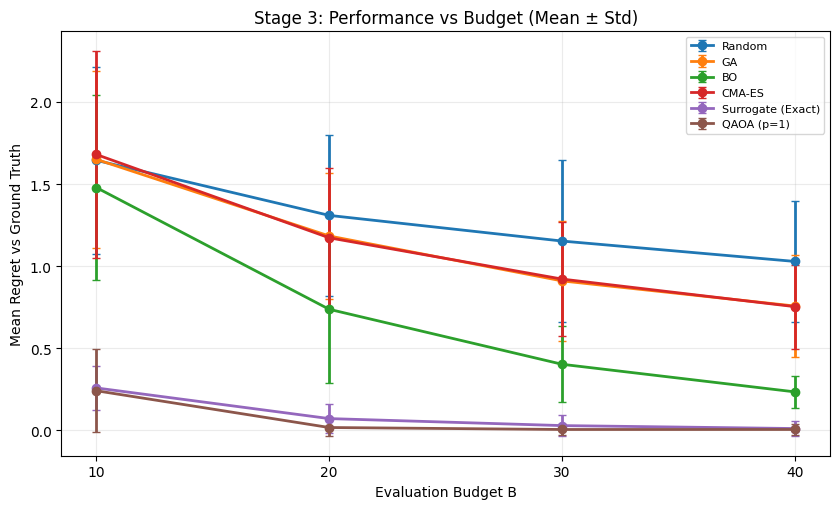

In [15]:
import numpy as np
import matplotlib.pyplot as plt

plt.figure(figsize=(8.5, 5.2))

for method in METHOD_ORDER:
    means = []
    stds = []
    budgets = []

    for B in BUDGET_ORDER:
        if method in stage3_results[B]:
            regs = np.array(stage3_results[B][method]["regret"], dtype=float)
            means.append(np.mean(regs))
            stds.append(np.std(regs))
            budgets.append(B)

    plt.errorbar(
        budgets,
        means,
        yerr=stds,
        marker="o",
        capsize=3,
        linewidth=2,
        label=method
    )

plt.xticks(BUDGET_ORDER)
plt.xlabel("Evaluation Budget B")
plt.ylabel("Mean Regret vs Ground Truth")
plt.title("Stage 3: Performance vs Budget (Mean ± Std)")
plt.grid(True, alpha=0.25)
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()


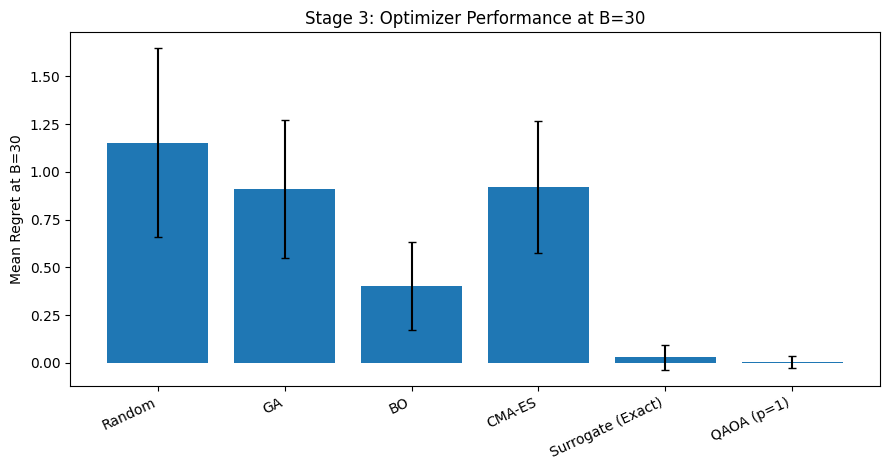

In [16]:
chosen_B = 30   # change to 20 if you want

labels = METHOD_ORDER
means = np.array([np.mean(stage3_results[chosen_B][m]["regret"]) for m in labels])
stds  = np.array([np.std(stage3_results[chosen_B][m]["regret"]) for m in labels])

plt.figure(figsize=(9, 4.8))
x = np.arange(len(labels))
plt.bar(x, means, yerr=stds, capsize=3)
plt.xticks(x, labels, rotation=25, ha="right")
plt.ylabel(f"Mean Regret at B={chosen_B}")
plt.title(f"Stage 3: Optimizer Performance at B={chosen_B}")
plt.tight_layout()
plt.show()


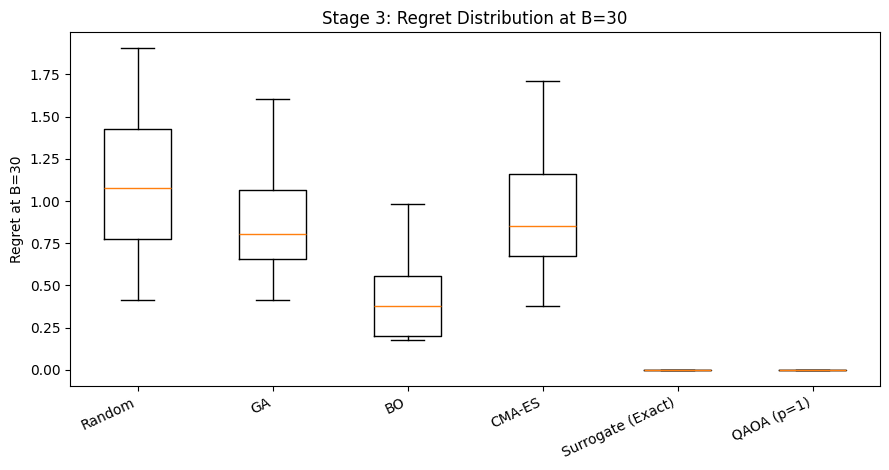

In [17]:
chosen_B = 30   # or 20

labels = METHOD_ORDER
data = [np.array(stage3_results[chosen_B][m]["regret"], dtype=float) for m in labels]

plt.figure(figsize=(9, 4.8))
plt.boxplot(data, labels=labels, showfliers=False)
plt.xticks(rotation=25, ha="right")
plt.ylabel(f"Regret at B={chosen_B}")
plt.title(f"Stage 3: Regret Distribution at B={chosen_B}")
plt.tight_layout()
plt.show()


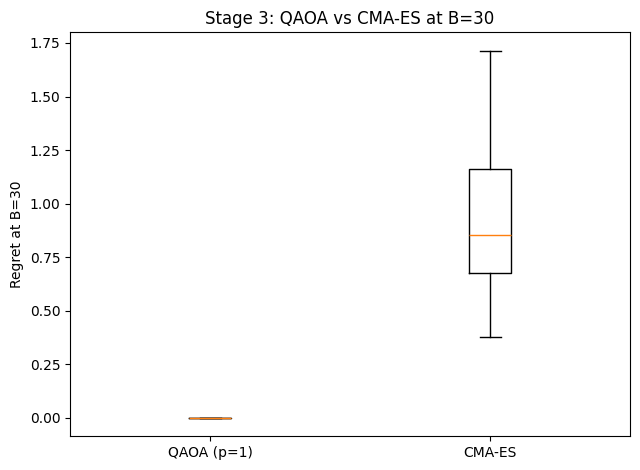

In [18]:
compare_B = 30   # or 20

qaoa = np.array(stage3_results[compare_B]["QAOA (p=1)"]["regret"], dtype=float)
cma  = np.array(stage3_results[compare_B]["CMA-ES"]["regret"], dtype=float)

plt.figure(figsize=(6.5, 4.8))
plt.boxplot([qaoa, cma], labels=["QAOA (p=1)", "CMA-ES"], showfliers=False)
plt.ylabel(f"Regret at B={compare_B}")
plt.title(f"Stage 3: QAOA vs CMA-ES at B={compare_B}")
plt.tight_layout()
plt.show()


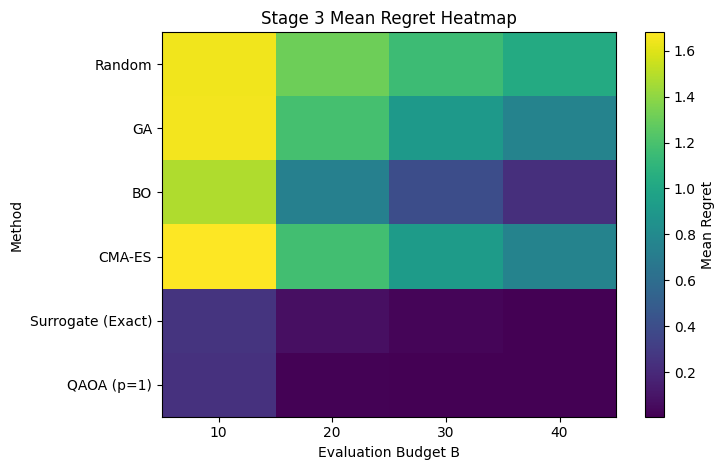

In [19]:
import numpy as np
import matplotlib.pyplot as plt

method_names = list(stage3_methods.keys())
budget_names = BUDGETS

M = np.zeros((len(method_names), len(budget_names)), dtype=float)

for i, method in enumerate(method_names):
    for j, B in enumerate(budget_names):
        M[i, j] = np.mean(stage3_results[B][method]["regret"])

plt.figure(figsize=(7.5, 4.8))
im = plt.imshow(M, aspect="auto")
plt.colorbar(im, label="Mean Regret")
plt.xticks(np.arange(len(budget_names)), budget_names)
plt.yticks(np.arange(len(method_names)), method_names)
plt.xlabel("Evaluation Budget B")
plt.ylabel("Method")
plt.title("Stage 3 Mean Regret Heatmap")
plt.tight_layout()
plt.show()


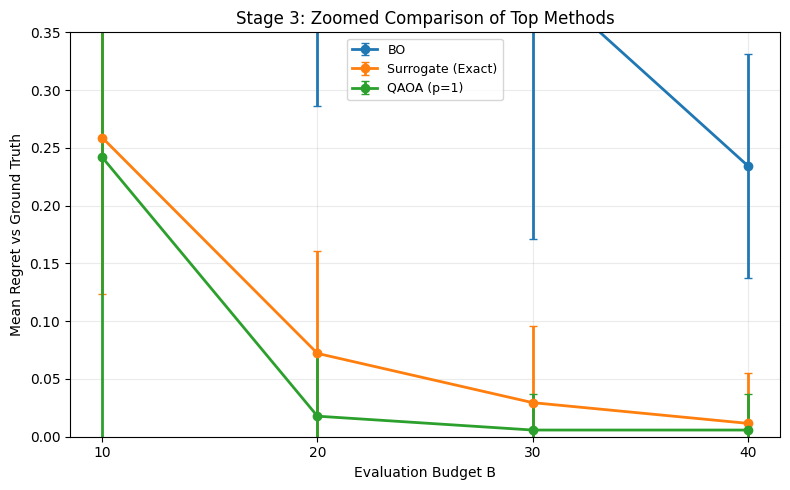

In [20]:
import numpy as np
import matplotlib.pyplot as plt

budgets = sorted(stage3_results.keys())

# Choose the methods you want visible in the zoomed view
plot_methods = ["BO", "Surrogate (Exact)", "QAOA (p=1)"]

plt.figure(figsize=(8, 5))

for method in plot_methods:
    means = np.array([np.mean(stage3_results[B][method]["regret"]) for B in budgets])
    stds  = np.array([np.std(stage3_results[B][method]["regret"]) for B in budgets])

    plt.errorbar(
        budgets,
        means,
        yerr=stds,
        marker="o",
        capsize=3,
        linewidth=2,
        label=method
    )

plt.xticks(budgets)
plt.xlabel("Evaluation Budget B")
plt.ylabel("Mean Regret vs Ground Truth")
plt.title("Stage 3: Zoomed Comparison of Top Methods")
plt.ylim(0.0, 0.35)   # adjust if you want even tighter
plt.grid(True, alpha=0.25)
plt.legend(fontsize=9)
plt.tight_layout()
plt.show()
